In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib
from trapping_effects import *
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# define color maps
mycolors = [(0.0, "#32006e"), (0.1, "#4b2e83"), (0.35, "#30719c"), (0.5, "#38948f"), (0.65, "#47c954"), (1.0, "#FFFF00")]
myMap = LinearSegmentedColormap.from_list('myMap', mycolors)

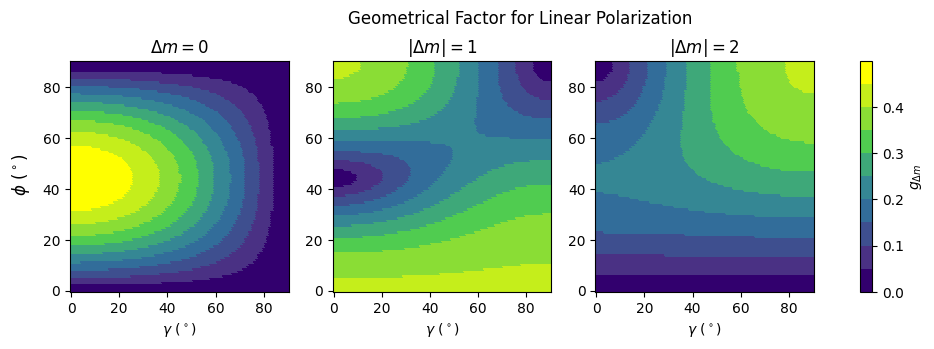

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
plt.tick_params(axis='both', labelsize=10)

phis = np.linspace(0, np.pi/2, 100)
gammas = np.linspace(0, np.pi/2, 100)

gf_m0_arr = np.ones(shape = (len(phis), len(gammas)))
gf_m1_arr = np.ones(shape = (len(phis), len(gammas)))
gf_m2_arr = np.ones(shape = (len(phis), len(gammas)))

for i in range(len(phis)):
    for j in range(len(gammas)):
        gf_m0_arr[i][j] = Geometric_Factors(0, phis[i], gammas[j])
        gf_m1_arr[i][j] = Geometric_Factors(1, phis[i], gammas[j])
        gf_m2_arr[i][j] = Geometric_Factors(2, phis[i], gammas[j])

m_min, m_max = min(gf_m0_arr.min(), gf_m1_arr.min(), gf_m2_arr.min()), max(gf_m0_arr.max(), gf_m1_arr.max(), gf_m2_arr.max())

cmap = myMap.resampled(10)

c0 = ax[0].pcolormesh(gammas*180/np.pi, phis*180/np.pi, gf_m0_arr, cmap=cmap, edgecolor="face", vmin=m_min, vmax=m_max)
c1 = ax[1].pcolormesh(gammas*180/np.pi, phis*180/np.pi, gf_m1_arr, cmap=cmap, edgecolor="face",vmin=m_min, vmax=m_max)
c2 = ax[2].pcolormesh(gammas*180/np.pi, phis*180/np.pi, gf_m2_arr, cmap=cmap, edgecolor="face",vmin=m_min, vmax=m_max)


ax[0].set_title(r"$\Delta m = 0$")
ax[1].set_title(r"$|\Delta m| = 1$")
ax[2].set_title(r"$|\Delta m| = 2$")
ax[0].set_xlabel(r"$\gamma$ ($^\circ$)")
ax[1].set_xlabel(r"$\gamma$ ($^\circ$)")
ax[2].set_xlabel(r"$\gamma$ ($^\circ$)")
fig.supylabel(r"$\phi$ ($^\circ$)", x=.075)

cbar = fig.colorbar(c0, ax=ax)
cbar.set_label(r"$g_{\Delta m}$")
cbar.ax.tick_params(labelsize=10)

fig.suptitle("figs/Geometrical Factor for Linear Polarization", y=1.05)
plt.savefig("figs/Geometrical Factor.png", bbox_inches='tight', dpi=300)
plt.savefig("figs/Geometrical Factor.pdf", bbox_inches='tight');

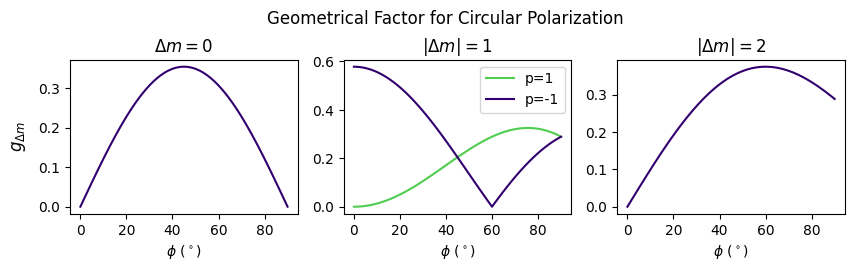

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(10, 2))
colors2 =myMap(np.linspace(0,1,4))
plt.tick_params(axis='both', labelsize=10)

phis = np.linspace(0, np.pi/2, 100)

ax[0].plot(phis*180/np.pi, [Geometric_Factors(0, phi, p=1) for phi in phis], color=colors2[0])
ax[1].plot(phis*180/np.pi,[Geometric_Factors(1, phi, p=1) for phi in phis], color=colors2[2], label="p=1")
ax[1].plot(phis*180/np.pi,[Geometric_Factors(1, phi, p=-1) for phi in phis], color=colors2[0], label="p=-1") # something might be flipped here bc id expect the opposite results?
ax[2].plot(phis*180/np.pi,[Geometric_Factors(2, phi, p=1) for phi in phis], color=colors2[0])

ax[0].set_title(r"$\Delta m = 0$")
ax[1].set_title(r"$|\Delta m| = 1$")
ax[2].set_title(r"$|\Delta m| = 2$")
ax[0].set_xlabel(r"$\phi$ ($^\circ$)")
ax[1].set_xlabel(r"$\phi$ ($^\circ$)")
ax[2].set_xlabel(r"$\phi$ ($^\circ$)")
ax[1].legend()
fig.supylabel(r"$g_{\Delta m}$", x=0.065)
fig.suptitle("figs/Geometrical Factor for Circular Polarization", y=1.13)
plt.savefig("figs/Circ Geometrical Factor.png", bbox_inches='tight', dpi=300)
plt.savefig("figs/Circ Geometrical Factor.pdf", bbox_inches='tight');

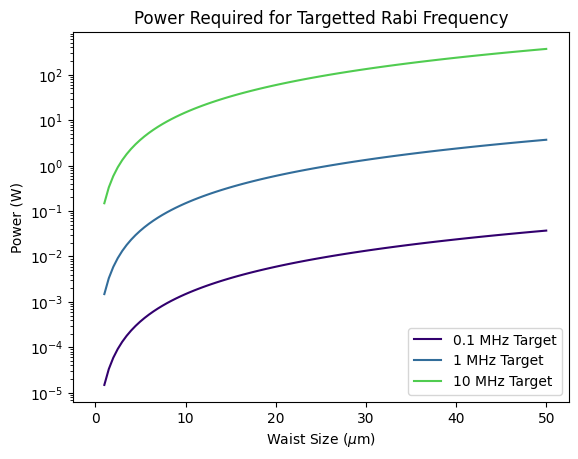

In [ ]:
fig, ax = plt.subplots()
colors3 = myMap(np.linspace(0,1,4))

excited_linewidth = 2*np.pi*1/(1.168) # approximately this bc the transition is about 1.168s and we need it in rads/sec
wave_vec_mag = 2*np.pi/(729*10**(-9))
m = 1/2
m_prime = 5/2
phi = np.pi/2
p = None
gamma = np.pi/2

waist_sizes = np.linspace(1, 50, 100)*10**(-6)
target_rabis = [10*10**5, 10*10**6, 10*10**7]
targets = [.1, 1, 10]
counter = 0

for target_rabi in target_rabis:
    ax.plot(waist_sizes*10**6, [find_power(2*np.pi*target_rabi, waist_size, excited_linewidth, wave_vec_mag, m, m_prime, phi=phi, gamma=gamma, p=p) for waist_size in waist_sizes], color=colors3[counter], label=f"{targets[counter]} MHz Target")
    counter += 1
    
ax.hlines(1*10**(-3), xmin=0, xmax=50*10**(-6), color="gray")
ax.set_yscale("log")
ax.set_ylabel("Power (W)")
ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_title("Power Required for Targetted Rabi Frequency")
ax.legend()
plt.savefig("figs/Power vs Waist.png", bbox_inches="tight", dpi=300)
plt.savefig("figs/Power vs Waist.pdf", bbox_inches="tight");
# about a milliwatt

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\rlhaa\AppData\Local\Temp\ipykernel_13136\1084596036.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(waist_sizes*10**6, instab, color=colors3[counter], label=f"{inst[counter]} $\mu$m Instability")


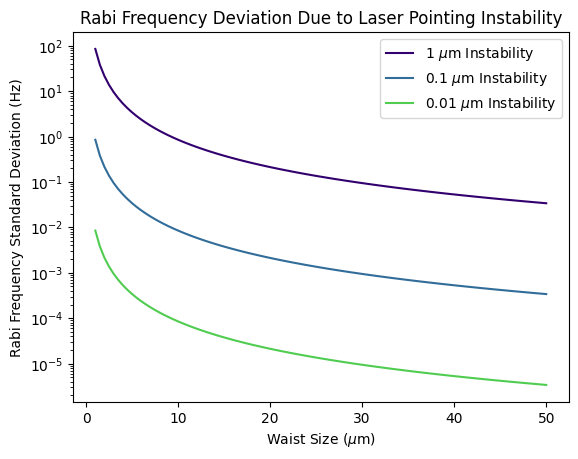

In [ ]:
# second order approximation for on-axis laser
fig, ax = plt.subplots()
rabi_initial = 10*6

waist_sizes = np.linspace(1, 50, 100)*10**(-6)
pointing_instabilities = [10**(-6), 10**(-7), 10**(-8)]
inst = [1, 0.1, 0.01]
instabarr = [[],[],[]]
counter = 0 
for pointing_instability in pointing_instabilities:
    instab = [np.sqrt(2)*rabi_initial*pointing_instability**2/waist_size**2 for waist_size in waist_sizes]
    ax.plot(waist_sizes*10**6, instab, color=colors3[counter], label=f"{inst[counter]} $\mu$m Instability")
    instabarr[counter] = instab
    counter += 1
    
ax.set_ylabel("Rabi Frequency Standard Deviation (Hz)")
ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_title(f"Rabi Frequency Deviation Due to Laser Pointing Instability")
ax.set_yscale("log")
ax.legend()
plt.savefig("figs/On axis dev.pdf", dpi=300)
plt.savefig("figs/On axis dev.png");

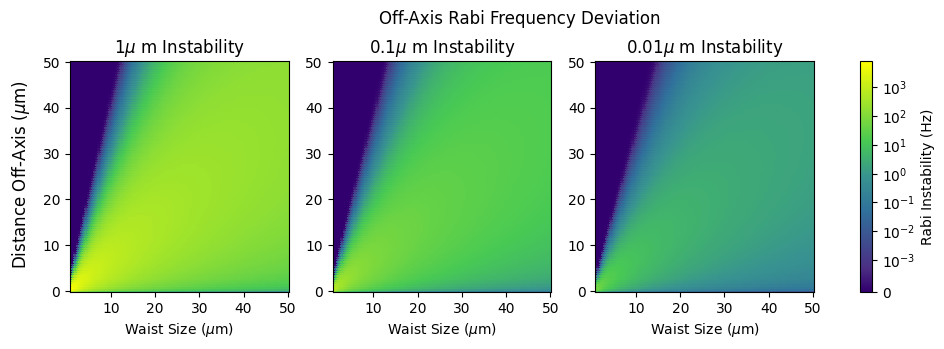

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
rabi_initial = 100*10**2

waist_sizes = np.linspace(1, 50, 100)*10**(-6)
radii = np.linspace(0.1, 50, 100)*10**(-6)

pi_6_arr = np.ones(shape = (len(waist_sizes), len(radii)))
pi_7_arr = np.ones(shape = (len(waist_sizes), len(radii)))
pi_8_arr = np.ones(shape = (len(waist_sizes), len(radii)))

for i in range(len(waist_sizes)):
    for j in range(len(radii)):
        r = radii[j]
        waist = waist_sizes[i]
        pi_6_arr[j][i] = np.abs(rabi_off_axis(r, waist, 2*np.pi*rabi_initial)*10**(-6)*2*r/waist**2)/(2*np.pi)
        pi_7_arr[j][i] = np.abs(rabi_off_axis(r, waist, 2*np.pi*rabi_initial)*10**(-7)*2*r/waist**2)/(2*np.pi)
        pi_8_arr[j][i] = np.abs(rabi_off_axis(r, waist, 2*np.pi*rabi_initial)*10**(-8)*2*r/waist**2)/(2*np.pi)

m_min, m_max = min(pi_6_arr.min(), pi_7_arr.min(), pi_8_arr.min()), max(pi_6_arr.max(), pi_7_arr.max(), pi_8_arr.max())

cmap = myMap.resampled(20) #discrete color map
cmap = myMap # continuous color map

c0 = ax[0].pcolormesh(waist_sizes*10**6, radii*10**6, pi_6_arr, cmap=cmap,edgecolor="face", norm=matplotlib.colors.SymLogNorm(linthresh = 1*10**-3, vmin=m_min, vmax=m_max))
c1 = ax[1].pcolormesh(waist_sizes*10**6, radii*10**6, pi_7_arr, cmap=cmap,edgecolor="face", norm=matplotlib.colors.SymLogNorm(linthresh = 1*10**-3, vmin=m_min, vmax=m_max))
c2 = ax[2].pcolormesh(waist_sizes*10**6, radii*10**6, pi_8_arr, cmap=cmap,edgecolor="face", norm=matplotlib.colors.SymLogNorm(linthresh = 1*10**-3, vmin=m_min, vmax=m_max))


ax[0].set_title(r"$1\mu$ m Instability")
ax[1].set_title(r"$0.1\mu$ m Instability")
ax[2].set_title(r"$0.01\mu$ m Instability")
ax[0].set_xlabel(r"Waist Size ($\mu$m)")
ax[1].set_xlabel(r"Waist Size ($\mu$m)")
ax[2].set_xlabel(r"Waist Size ($\mu$m)")
fig.supylabel(r"Distance Off-Axis ($\mu$m)", x=.075)

cbar = fig.colorbar(c0, ax=ax)
cbar.set_label(r"Rabi Instability (Hz)")

fig.suptitle("Off-Axis Rabi Frequency Deviation", y=1.05)
plt.savefig("figs/Off axis dev.pdf", bbox_inches='tight', dpi=300)
plt.savefig("figs/Off axis dev.png", bbox_inches='tight');

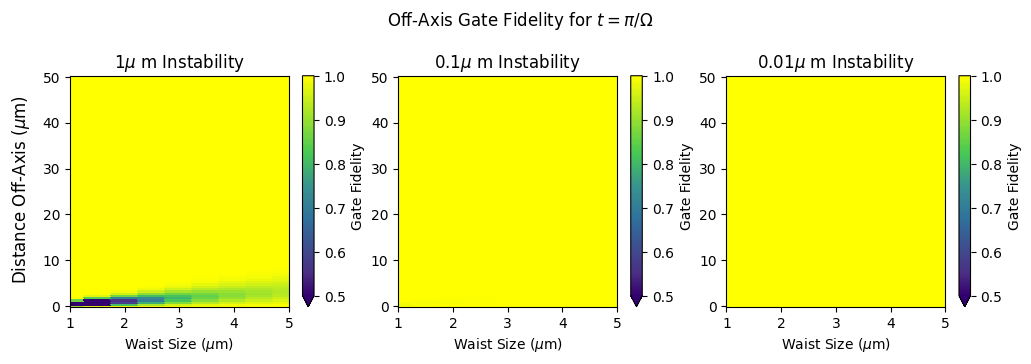

In [53]:
fig, ax = plt.subplots(1,3, figsize=(12,3))
rabi_initial = 100*10**2
fidel_6_arr = np.ones(shape = (len(waist_sizes), len(radii)))
fidel_7_arr = np.ones(shape = (len(waist_sizes), len(radii)))
fidel_8_arr = np.ones(shape = (len(waist_sizes), len(radii)))

for i in range(len(pi_6_arr)):
    for j in range(len(pi_6_arr[i])):
        fidel_6_arr[i][j] = (1-(np.pi*pi_6_arr[i][j]/rabi_initial/2)**2)
        fidel_7_arr[i][j] = (1-(np.pi*pi_7_arr[i][j]/rabi_initial/2)**2)
        fidel_8_arr[i][j] = (1-(np.pi*pi_8_arr[i][j]/rabi_initial/2)**2)

m_min, m_max = min(fidel_6_arr.min(), fidel_7_arr.min(), fidel_8_arr.min()), max(fidel_6_arr.max(), fidel_7_arr.max(), fidel_8_arr.max())
cmap = myMap.resampled(10) #discrete color map
cmap = myMap # continuous color map

c0 = ax[0].pcolormesh(waist_sizes*10**6, radii*10**6, fidel_6_arr, cmap=cmap,edgecolor="face", vmin=0.5, vmax=m_max)
c1 = ax[1].pcolormesh(waist_sizes*10**6, radii*10**6, fidel_7_arr, cmap=cmap,edgecolor="face", vmin=0.5, vmax=m_max)
c2 = ax[2].pcolormesh(waist_sizes*10**6, radii*10**6, fidel_8_arr, cmap=cmap,edgecolor="face", vmin=0.5, vmax=m_max)


ax[0].set_title(r"$1\mu$ m Instability")
ax[1].set_title(r"$0.1\mu$ m Instability")
ax[2].set_title(r"$0.01\mu$ m Instability")
ax[0].set_xlabel(r"Waist Size ($\mu$m)")
ax[1].set_xlabel(r"Waist Size ($\mu$m)")
ax[2].set_xlabel(r"Waist Size ($\mu$m)")
fig.supylabel(r"Distance Off-Axis ($\mu$m)", x=.075)

cbar0 = fig.colorbar(c0, ax=ax[0], extend="min")
cbar0.set_label(r"Gate Fidelity")
cbar1 = fig.colorbar(c1, ax=ax[1], extend="min")
cbar1.set_label(r"Gate Fidelity")
cbar2 = fig.colorbar(c2, ax=ax[2], extend="min")
cbar2.set_label(r"Gate Fidelity")
ax[0].set_xlim(1, 5)
ax[1].set_xlim(1, 5)
ax[2].set_xlim(1, 5)

fig.suptitle(r"Off-Axis Gate Fidelity for $t=\pi/\Omega$", y=1.1);
# plt.savefig("Off axis gate.pdf", bbox_inches='tight')
# plt.savefig("Off axis gate.png", bbox_inches='tight');

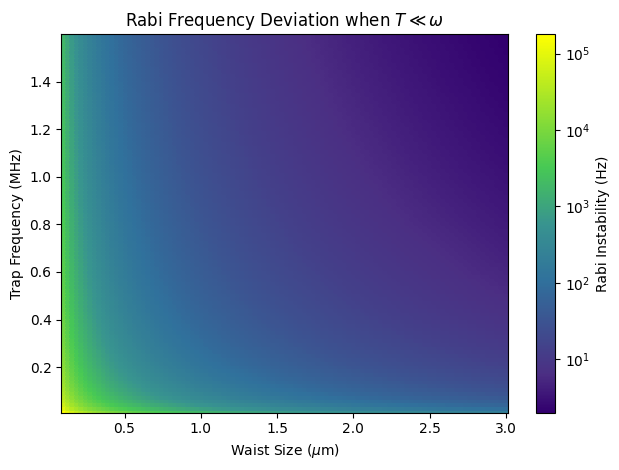

In [ ]:
# second order approximation for on-axis laser
calcium_mass = 6.6358*10**(-26)

fig, ax = plt.subplots()
rabi_initial = 10**6

waist_sizes = np.linspace(0.1, 3, 100)*10**(-6)

trap_freqs = np.linspace(0.1, 10, 100)*10**6
delta_xs = [np.sqrt(h_bar/(4*np.pi*calcium_mass*trap_freq)) for trap_freq in trap_freqs]

dx_arr = np.ones(shape = (len(waist_sizes), len(delta_xs)))

for i in range(len(waist_sizes)):
    for j in range(len(delta_xs)):
        dx = delta_xs[j]
        waist_size = waist_sizes[i]
        dx_arr[j][i] = np.sqrt(2)*rabi_initial*dx**2/waist_size**2

m_min, m_max = dx_arr.min(), dx_arr.max()

cmap = myMap.resampled(15) #discrete color map
cmap = myMap # continuous color map

c0 = ax.pcolormesh(waist_sizes*10**6, trap_freqs/(2*np.pi)*10**(-6), dx_arr, cmap=cmap,edgecolor="face", norm=matplotlib.colors.SymLogNorm(linthresh = 1*10**-3, vmin=m_min, vmax=m_max))

ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_ylabel(r"Trap Frequency (MHz)")

cbar = fig.colorbar(c0, ax=ax)
cbar.set_label(r"Rabi Instability (Hz)")
ax.set_title(r"Rabi Frequency Deviation when $T \ll \omega$")
plt.tight_layout()
plt.savefig("figs/Freq var.pdf", dpi=300)
plt.savefig("figs/Freq var.png");

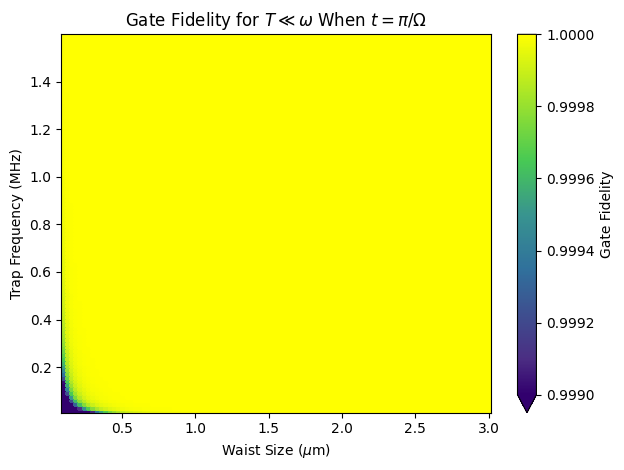

In [183]:
fig, ax = plt.subplots()
rabi_initial = 10**6

dx_fidel_arr = np.ones(shape = (len(waist_sizes), len(delta_xs)))

for i in range(len(dx_arr)):
    for j in range(len(dx_arr[i])):
        dx_fidel_arr[i][j] = (1-(np.pi*dx_arr[i][j]/rabi_initial)**2/4)

m_min, m_max = dx_fidel_arr.min(), dx_fidel_arr.max()

cmap = myMap.resampled(15) #discrete color map
cmap = myMap # continuous color map

#c0 = ax.pcolormesh(waist_sizes*10**6, trap_freqs/(2*np.pi)*10**(-6), dx_fidel_arr, cmap=cmap,edgecolor="face", norm=matplotlib.colors.LogNorm(vmin=m_min, vmax=m_max))
c0 = ax.pcolormesh(waist_sizes*10**6, trap_freqs/(2*np.pi)*10**(-6), dx_fidel_arr, cmap=cmap,edgecolor="face", vmin=0.999, vmax=1)

ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_ylabel(r"Trap Frequency (MHz)")

cbar.ax.tick_params(labelsize=15)
cbar = fig.colorbar(c0, ax=ax, extend="min")
cbar.set_label(r"Gate Fidelity")
ax.set_title(r"Gate Fidelity for $T \ll \omega$ When $t=\pi/\Omega$")
plt.tight_layout();
# plt.savefig("Freq var 5mum.pdf")
# plt.savefig("Freq var 5mum.png");

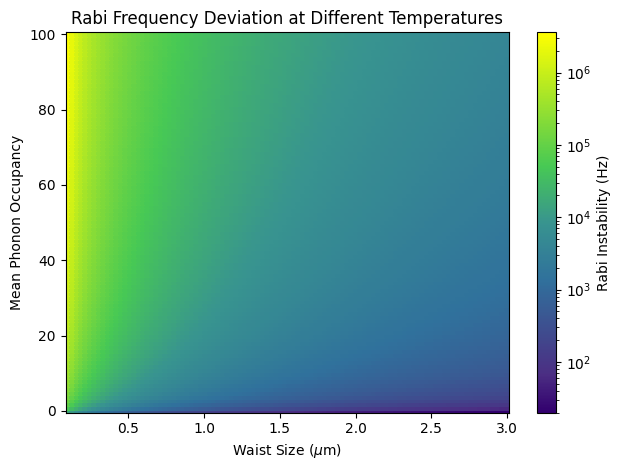

In [ ]:
# second order approximation for on-axis laser
calcium_mass = 6.6358*10**(-26)

fig, ax = plt.subplots()
rabi_initial = 10**6

waist_sizes = np.linspace(0.1, 3, 100)*10**(-6)

trap_freq = 10**6
phonon_occs = np.linspace(0, 100, 100)
delta_xs2 = [np.sqrt(h_bar/(4*np.pi*calcium_mass*trap_freq)*(2*phonon_occ+1)) for phonon_occ in phonon_occs]

dx_arr2 = np.ones(shape = (len(delta_xs2), len(waist_sizes)))

for i in range(len(waist_sizes)):
    for j in range(len(delta_xs2)):
        dx = delta_xs2[j]
        waist_size = waist_sizes[i]
        dx_arr2[j][i] = np.sqrt(2)*rabi_initial*dx**2/waist_size**2

m_min, m_max = dx_arr2.min(), dx_arr2.max()

cmap = myMap.resampled(15) #discrete color map
cmap = myMap # continuous color map

c = ax.pcolormesh(waist_sizes*10**6, phonon_occs, dx_arr2, cmap=cmap,edgecolor="face", norm=matplotlib.colors.LogNorm(vmin=m_min, vmax=m_max))

ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_ylabel(r"Mean Phonon Occupancy")

cbar = fig.colorbar(c, ax=ax)
cbar.set_label(r"Rabi Instability (Hz)")
ax.set_title(r"Rabi Frequency Deviation at Different Temperatures")
plt.tight_layout()
plt.savefig("figs/Phonon var.pdf", dpi=300)
plt.savefig("figs/Phonon var.png");

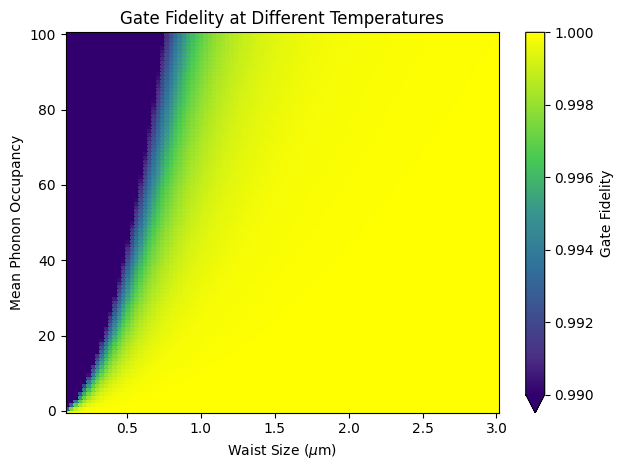

In [ ]:
fig, ax = plt.subplots()
rabi_initial = 10**6

dx_fidel_arr2 = np.ones(shape = (len(waist_sizes), len(delta_xs)))

for i in range(len(dx_arr2)):
    for j in range(len(dx_arr2[i])):
        dx_fidel_arr2[i][j] = (1-(np.pi*dx_arr2[i][j]/rabi_initial)**2/4)

m_min, m_max = dx_fidel_arr2.min(), dx_fidel_arr2.max()

#cmap = plt.colormaps['viridis'].resampled(15) #discrete color map
cmap = myMap # continuous color map

c0 = ax.pcolormesh(waist_sizes*10**6, phonon_occs, dx_fidel_arr2, cmap=cmap,edgecolor="face", vmin=0.99, vmax=1)

ax.set_xlabel(r"Waist Size ($\mu$m)")
ax.set_ylabel(r"Mean Phonon Occupancy")


cbar = fig.colorbar(c0, ax=ax, extend="min")
cbar.set_label(r"Gate Fidelity")
ax.set_title(r"Gate Fidelity at Different Temperatures")
plt.tight_layout()
plt.savefig("figs/phonon gate 5mum.pdf", dpi=300)
plt.savefig("figs/phonon gate 5mum.png");